# Dataset accidentes de tráfico

Este notebook analiza el dataset de accidentes de tráfico de Chicago (`Traffic_Crashes_-_Crashes_20260801.csv`).

**Información del dataset:**

Los datos muestran información sobre cada accidente de tráfico ocurrido en las calles de la ciudad, bajo la jurisdicción del Departamento de Policía de Chicago (CPD). Quedan excluidos de este conjunto de datos los accidentes de tráfico ocurridos dentro de los límites de la ciudad en los que el CPD no sea el cuerpo policial encargado de la intervención, normalmente accidentes en autopistas interestatales, rampas de acceso a autopistas y en carreteras locales a lo largo del límite municipal.

- Metadata:

| Propietario |  Período | Frecuencia | 
|---|---|---|
|Departamento de Policía de Chicago | 2015 - actualidad| Diario|

## 0. Importación de paquetes

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import folium
from folium.plugins import HeatMap

from EDA_general import *

## 1. EDA
### 1.1. Carga y visión general

In [2]:
df = pd.read_csv("data/Traffic_Crashes_-_Crashes_20260801.csv", low_memory=False)

In [3]:
resumen_general(df)

Dimensiones: 1,080,190 filas x 49 columnas

Tipos de dato por columna:
CRASH_RECORD_ID                      str
CRASH_DATE_EST_I                     str
CRASH_DATE                           str
POSTED_SPEED_LIMIT                 int64
TRAFFIC_CONTROL_DEVICE               str
DEVICE_CONDITION                     str
WEATHER_CONDITION                    str
LIGHTING_CONDITION                   str
FIRST_CRASH_TYPE                     str
TRAFFICWAY_TYPE                      str
LANE_CNT                             str
ALIGNMENT                            str
ROADWAY_SURFACE_COND                 str
ROAD_DEFECT                          str
REPORT_TYPE                          str
CRASH_TYPE                           str
INTERSECTION_RELATED_I               str
NOT_RIGHT_OF_WAY_I                   str
HIT_AND_RUN_I                        str
DAMAGE                               str
DATE_POLICE_NOTIFIED                 str
PRIM_CONTRIBUTORY_CAUSE              str
SEC_CONTRIBUTORY_CAUSE     

El dataset contiene **1.080.190 filas y 49 columnas**. En la limpieza vamos a eliminar la mayoría de las columnas, ya que la mayoría son campos administrativos que no aportan nada para predecir el tráfico.

### 1.2. Calidad de los datos

In [4]:
calidad_datos(df, id_col="CRASH_RECORD_ID")

Valores nulos por columna:
                                 nulos  % nulos
WORKERS_PRESENT_I              1078703    99.86
DOORING_I                      1076735    99.68
WORK_ZONE_TYPE                 1075799    99.59
WORK_ZONE_I                    1074408    99.46
PHOTOS_TAKEN_I                 1064494    98.55
STATEMENTS_TAKEN_I             1053908    97.57
NOT_RIGHT_OF_WAY_I             1032112    95.55
CRASH_DATE_EST_I               1002080    92.77
LANE_CNT                        881144    81.57
INTERSECTION_RELATED_I          832311    77.05
HIT_AND_RUN_I                   741002    68.60
REPORT_TYPE                      36728     3.40
LOCATION                          8409     0.78
LATITUDE                          8409     0.78
LONGITUDE                         8409     0.78
IDOT_CONTROL_NO                   2810     0.26
MOST_SEVERE_INJURY                2347     0.22
INJURIES_FATAL                    2332     0.22
INJURIES_INCAPACITATING           2332     0.22
INJURIES_NON_

Hay un grupo de columnas que casi siempre son nulas
(`WORKERS_PRESENT_I`, `DOORING_I`, `WORK_ZONE_TYPE`...), todas por encima del
80% de nulos. Tiene sentido ya que son campos que solo se rellenan en casos muy
concretos (obras, atropellos con puerta de coche, etc.), así que
no las vamos a usar.

Por otro lado, tenemos **0 registros duplicados** por `CRASH_RECORD_ID`.

Por último, `LATITUDE`/`LONGITUDE` tienen un 0.78% de nulos (unas 8.400 filas). Al ser
un porcentaje tan pequeño, las eliminaremos en la limpieza.

### 1.3. Análisis temporal

Fechas que no se pudieron parsear: 0
Rango de fechas: 2013-03-03 16:48:00 -> 2026-07-31 23:20:00


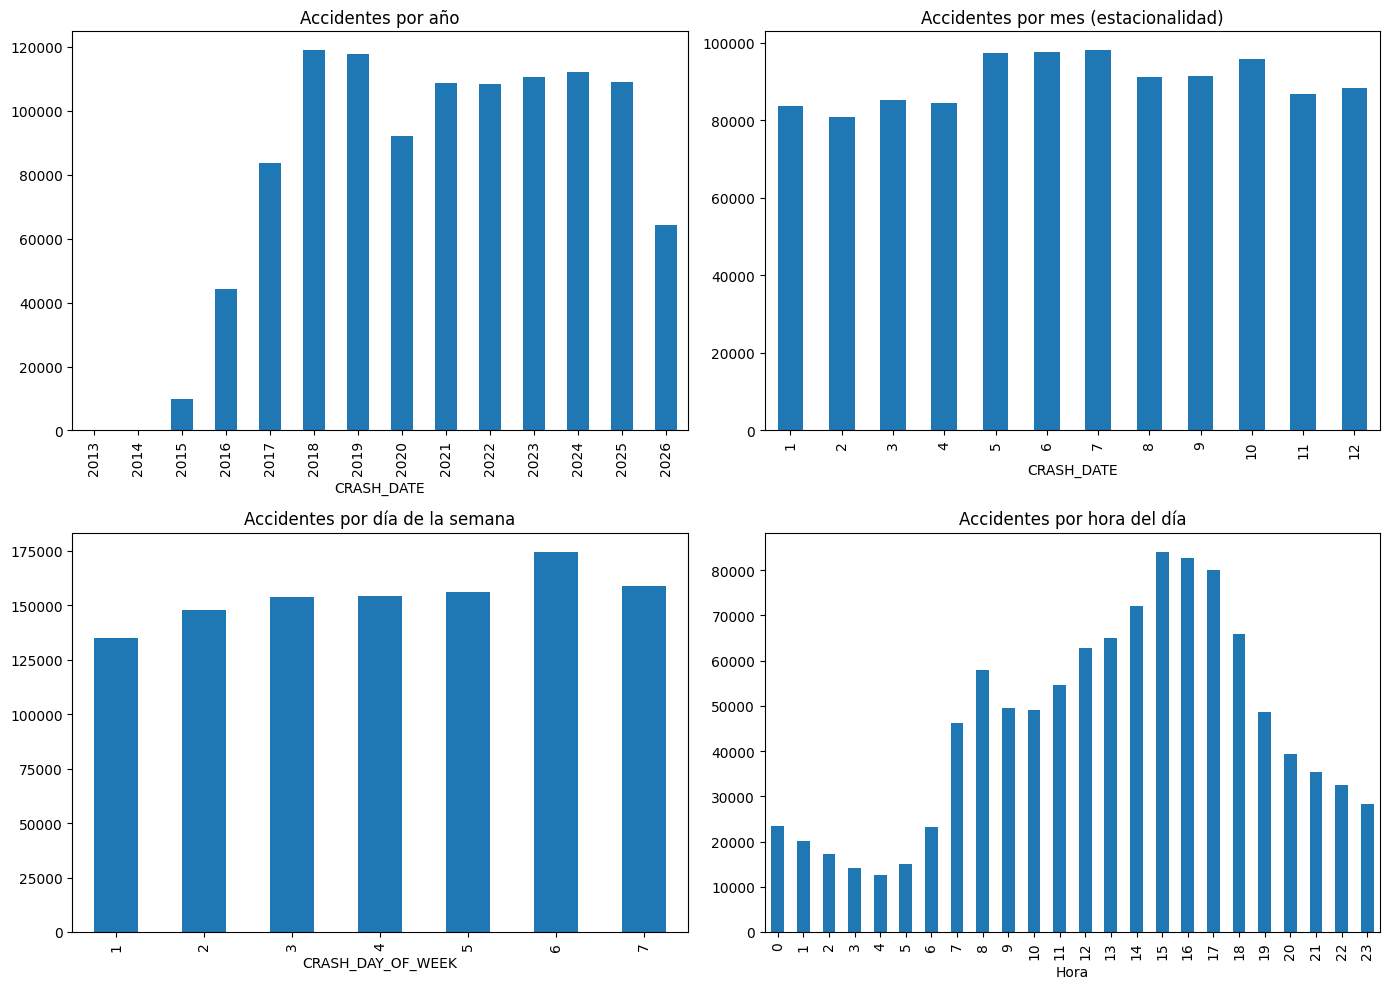

In [5]:
# formato de CRASH_DATE: "05/19/2026 11:15:00 PM"

df["date"] = analisis_temporal(
    df,
    date_col="CRASH_DATE",
    day_col="CRASH_DAY_OF_WEEK",
    hour_col="CRASH_HOUR",
    date_format="%m/%d/%Y %I:%M:%S %p",
    evento="Accidentes"
)

El rango de fechas va de **2013-03-03 a 2026-07-31**. Es un dataset que
Chicago actualiza prácticamente a diario, no un histórico cerrado.

En los gráficos podemos ver la estacionalidad y las horas punta, esto nos interesa para ver si las horas con
más accidentes coinciden con las horas de más congestión.

### 1.4. Análisis geográfico

In [ ]:
analisis_geografico(df, lat_col="LATITUDE", lon_col="LONGITUDE")

Solo un 0.8% de filas estan sin coordenadas (unas 8.400). En el heatmap se ve que los accidentes se almacenan en las vias más importantes de la ciudad, no están repartidas de forma uniforme.

### 1.5. Severidad y tipo de accidente

In [7]:
print("- Distribución de MOST_SEVERE_INJURY:")
print(df["MOST_SEVERE_INJURY"].value_counts(dropna=False))

print("\n- Distribución de CRASH_TYPE:")
print(df["CRASH_TYPE"].value_counts(dropna=False))

print("\n- Top 10 FIRST_CRASH_TYPE:")
print(df["FIRST_CRASH_TYPE"].value_counts(dropna=False).head(10))

- Distribución de MOST_SEVERE_INJURY:
MOST_SEVERE_INJURY
NO INDICATION OF INJURY     921858
NONINCAPACITATING INJURY     86661
REPORTED, NOT EVIDENT        50767
INCAPACITATING INJURY        17428
NaN                           2347
FATAL                         1129
Name: count, dtype: int64

- Distribución de CRASH_TYPE:
CRASH_TYPE
NO INJURY / DRIVE AWAY              787110
INJURY AND / OR TOW DUE TO CRASH    293080
Name: count, dtype: int64

- Top 10 FIRST_CRASH_TYPE:
FIRST_CRASH_TYPE
PARKED MOTOR VEHICLE            248795
REAR END                        234605
SIDESWIPE SAME DIRECTION        168919
TURNING                         156222
ANGLE                           116795
FIXED OBJECT                     49181
PEDESTRIAN                       26023
PEDALCYCLIST                     18273
SIDESWIPE OPPOSITE DIRECTION     14831
REAR TO FRONT                    12244
Name: count, dtype: int64


La gran mayoría de accidentes (**921,858 de 1,080,190, ~85%**) no tienen ninguna indicación de heridos. Los fatales son muy pocos en comparación (1,129, ~0.1%).

La gravedad del accidete es importnate para este trabajo, ya que si contamos accidentes por segmento sin tener en cuenta la gravedad, un cruce con muchos
golpes de aparcamiento pesaría igual que uno con accidentes graves, pero no es lo mismo de cara al tráfico. Por eso vamos a colapsar todo esto en una
sola columna de gravedad (`severity_level`) en vez de quedarnos con el desglose completo.

Por tipo de accidente (`FIRST_CRASH_TYPE`), el más común es
`PARKED MOTOR VEHICLE` (accidentes con coches aparcados) seguido de
alcances (`REAR END`), estos accidentes son menores y en general no generan grandes retenciones.

### 1.6. Análisis por calle

In [8]:
analisis_calles(df, street_col="STREET_NAME", dir_col="STREET_DIRECTION")

Top 15 'STREET_NAME' con más registros:
STREET_NAME
WESTERN AVE       29558
PULASKI RD        25823
CICERO AVE        24241
ASHLAND AVE       23436
HALSTED ST        20612
KEDZIE AVE        19025
MICHIGAN AVE      13828
NORTH AVE         12510
STATE ST          12005
CLARK ST          11591
GRAND AVE         11061
IRVING PARK RD    11022
CALIFORNIA AVE    10910
ARCHER AVE        10778
DAMEN AVE         10728
Name: count, dtype: int64

Distribución de STREET_DIRECTION:
STREET_DIRECTION
W      388429
S      358555
N      260716
E       72486
NaN         4
Name: count, dtype: int64


Las calles con más accidentes son avenidas grandes (Western, Pulaski, Cicero, Ashland...), lo que ocncuerda con el heatmap de antes.

## 2. Limpieza

Con el EDA ya hecho, nos quedamos solo con lo que necesitamos para el trabajo. La idea es preparar este dataset para poder cruzarlo más adelante con el de congestión y usarlo como variable de riesgo en el modelo de predicción de tráfico.

**Columnas que nos interesan:**
- `CRASH_DATE`, `CRASH_HOUR` : para alinear temporalmente con el dataset de congestión.
- `LATITUDE`, `LONGITUDE`, `STREET_DIRECTION` : para el cruce espacial.
- `STREET_NAME`, `STREET_NO` : alternativa por si el cruce espacial falla.
- `MOST_SEVERE_INJURY`, `INJURIES_FATAL` : para construir la variable de gravedad.
- `CRASH_RECORD_ID`

El resto de columnas (clima, tipo de vía, carriles, límite de velocidad...) las descartamos porque es información ya cubierta con otros datasets del proyecto.

In [9]:
col_temporal = ["CRASH_DATE", "CRASH_HOUR"]
col_geo = ["LATITUDE", "LONGITUDE", "STREET_NAME", "STREET_DIRECTION", "STREET_NO"]
col_severity = ["MOST_SEVERE_INJURY", "INJURIES_FATAL"]
col_id = ["CRASH_RECORD_ID"]

columnas = col_id + col_temporal + col_geo + col_severity
df = df[columnas].copy()
print(f"Tras seleccionar las columnas relevantes: {df.shape[1]} columnas")

Tras seleccionar las columnas relevantes: 10 columnas


### 2.1. Temporal

In [10]:
# formato datetime
df["CRASH_DATE"] = pd.to_datetime(df["CRASH_DATE"], format="%m/%d/%Y %I:%M:%S %p", errors="coerce")

# CRASH_HOUR debería estar informado si CRASH_DATE es válida
# si no, lo derivamos nosotros
df["CRASH_HOUR"] = df["CRASH_HOUR"].fillna(df["CRASH_DATE"].dt.hour)

# ordenamos cronológicamente
df = df.sort_values("CRASH_DATE").reset_index(drop=True)

### 2.2. Geográfico

In [11]:
# eliminamos filas sin coordenadas (0.8% del total)
df = df.dropna(subset=["LATITUDE", "LONGITUDE"])

n_sin_coords = df[["LATITUDE", "LONGITUDE"]].isnull().any(axis=1).sum()
print(f"Filas sin coordenadas tras la limpieza: {n_sin_coords}")

# normalizamos texto para facilitar el futuro cruce con el dataset de congestión
for col in ["STREET_NAME", "STREET_DIRECTION"]:
    df[col] = df[col].astype(str).str.strip().str.upper()

Filas sin coordenadas tras la limpieza: 0


### 2.3. Gravedad

In [12]:
# juntamos MOST_SEVERE_INJURY + INJURIES_FATAL en una única columna
# categórica de gravedad con 4 niveles: sin_heridos < leve < grave < fatal
df["MOST_SEVERE_INJURY"] = df["MOST_SEVERE_INJURY"].fillna("UNKNOWN").str.strip().str.upper()
df["INJURIES_FATAL"] = pd.to_numeric(df["INJURIES_FATAL"], errors="coerce").fillna(0)

mapa_gravedad = {
    "FATAL": "fatal",
    "INCAPACITATING INJURY": "grave",
    "NON-INCAPACITATING INJURY": "leve",
    "REPORTED, NOT EVIDENT": "leve",
    "NO INDICATION OF INJURY": "sin_heridos",
    "UNKNOWN": "sin_heridos",
}
df["severity_level"] = df["MOST_SEVERE_INJURY"].map(mapa_gravedad).fillna("sin_heridos")

# si hubo algún herido fatal en el conteo pero MOST_SEVERE_INJURY no lo
# refleja, forzamos la categoría "fatal"
n_forced_fatal = ((df["INJURIES_FATAL"] > 0) & (df["severity_level"] != "fatal")).sum()
df.loc[df["INJURIES_FATAL"] > 0, "severity_level"] = "fatal"
if n_forced_fatal:
    print(f"Corregidas {n_forced_fatal:,} filas a 'fatal' por INJURIES_FATAL > 0 "
          f"(inconsistentes con MOST_SEVERE_INJURY)")

print("\nDistribución final de severity_level:")
print(df["severity_level"].value_counts())

# eliminamos las columnas originales
df = df.drop(columns=["MOST_SEVERE_INJURY", "INJURIES_FATAL"])


Distribución final de severity_level:
severity_level
sin_heridos    1002934
leve             50413
grave            17314
fatal             1120
Name: count, dtype: int64


### 2.4. Quitamos el ID

In [13]:
# CRASH_RECORD_ID no aporta nada como variable predictiva, así que lo quitamos del
# resultado final
df = df.drop(columns=["CRASH_RECORD_ID"])

print(df.head())

           CRASH_DATE  CRASH_HOUR   LATITUDE  LONGITUDE      STREET_NAME  \
0 2013-03-03 16:48:00          16  41.975857 -87.708744       FOSTER AVE   
1 2013-06-01 20:29:00          20  42.005145 -87.689969       PRATT BLVD   
2 2014-01-18 18:14:00          18  41.885610 -87.638756          LAKE ST   
3 2014-01-21 07:40:00           7  41.760710 -87.561946     EXCHANGE AVE   
4 2014-02-24 19:45:00          19  41.884016 -87.701143  SACRAMENTO BLVD   

  STREET_DIRECTION  STREET_NO severity_level  
0                W       3200           leve  
1                W       2358    sin_heridos  
2                W        415    sin_heridos  
3                S       7400    sin_heridos  
4                N        199    sin_heridos  


Por lo tanto este dataset queda en: `CRASH_DATE`, `CRASH_HOUR`, `LATITUDE`,
`LONGITUDE`, `STREET_NAME`, `STREET_DIRECTION`, `STREET_NO`,
`severity_level`.

In [14]:
df.to_csv("data_clean/crashes.csv", index=False)